# Assignment 2: Exploratory Data Analysis and Preprocessing for Predictive Modeling
Impact of Remote Work on Mental Health: Stress Level Classification

**Dataset:** [Impact of Remote Work on Mental Health](https://www.kaggle.com/datasets/waqi786/remote-work-and-mental-health)

**Model:** Random Forest Classifier  

**Target:** Stress Level (High, Medium, Low)

**Goal:**  This notebook explores the correlation between remote work environments and employee mental health. It focuses on building a robust Scikit-Learn pipeline to handle high-variance survey data and utilizes feature importance analysis to identify key stress drivers.

#**1. Import Key Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
!pip install ydata_profiling

# Modeling Tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 3.7 MB/s eta 0:00:00


# **2. Data Loading**

In [3]:
df = pd.read_csv("Impact_of_Remote_Work_on_Mental_Health.csv")
print(f"Data Shape: {df.shape}")
df.head()

Data Shape: (5000, 20)


,Employee_ID,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,EMP0001,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,EMP0002,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,EMP0003,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor,North America
3,EMP0004,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,NaN,Poor,Europe
4,EMP0005,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


# **3. Exploratory Data Analysis**

Dataset Shape: (5000, 20)


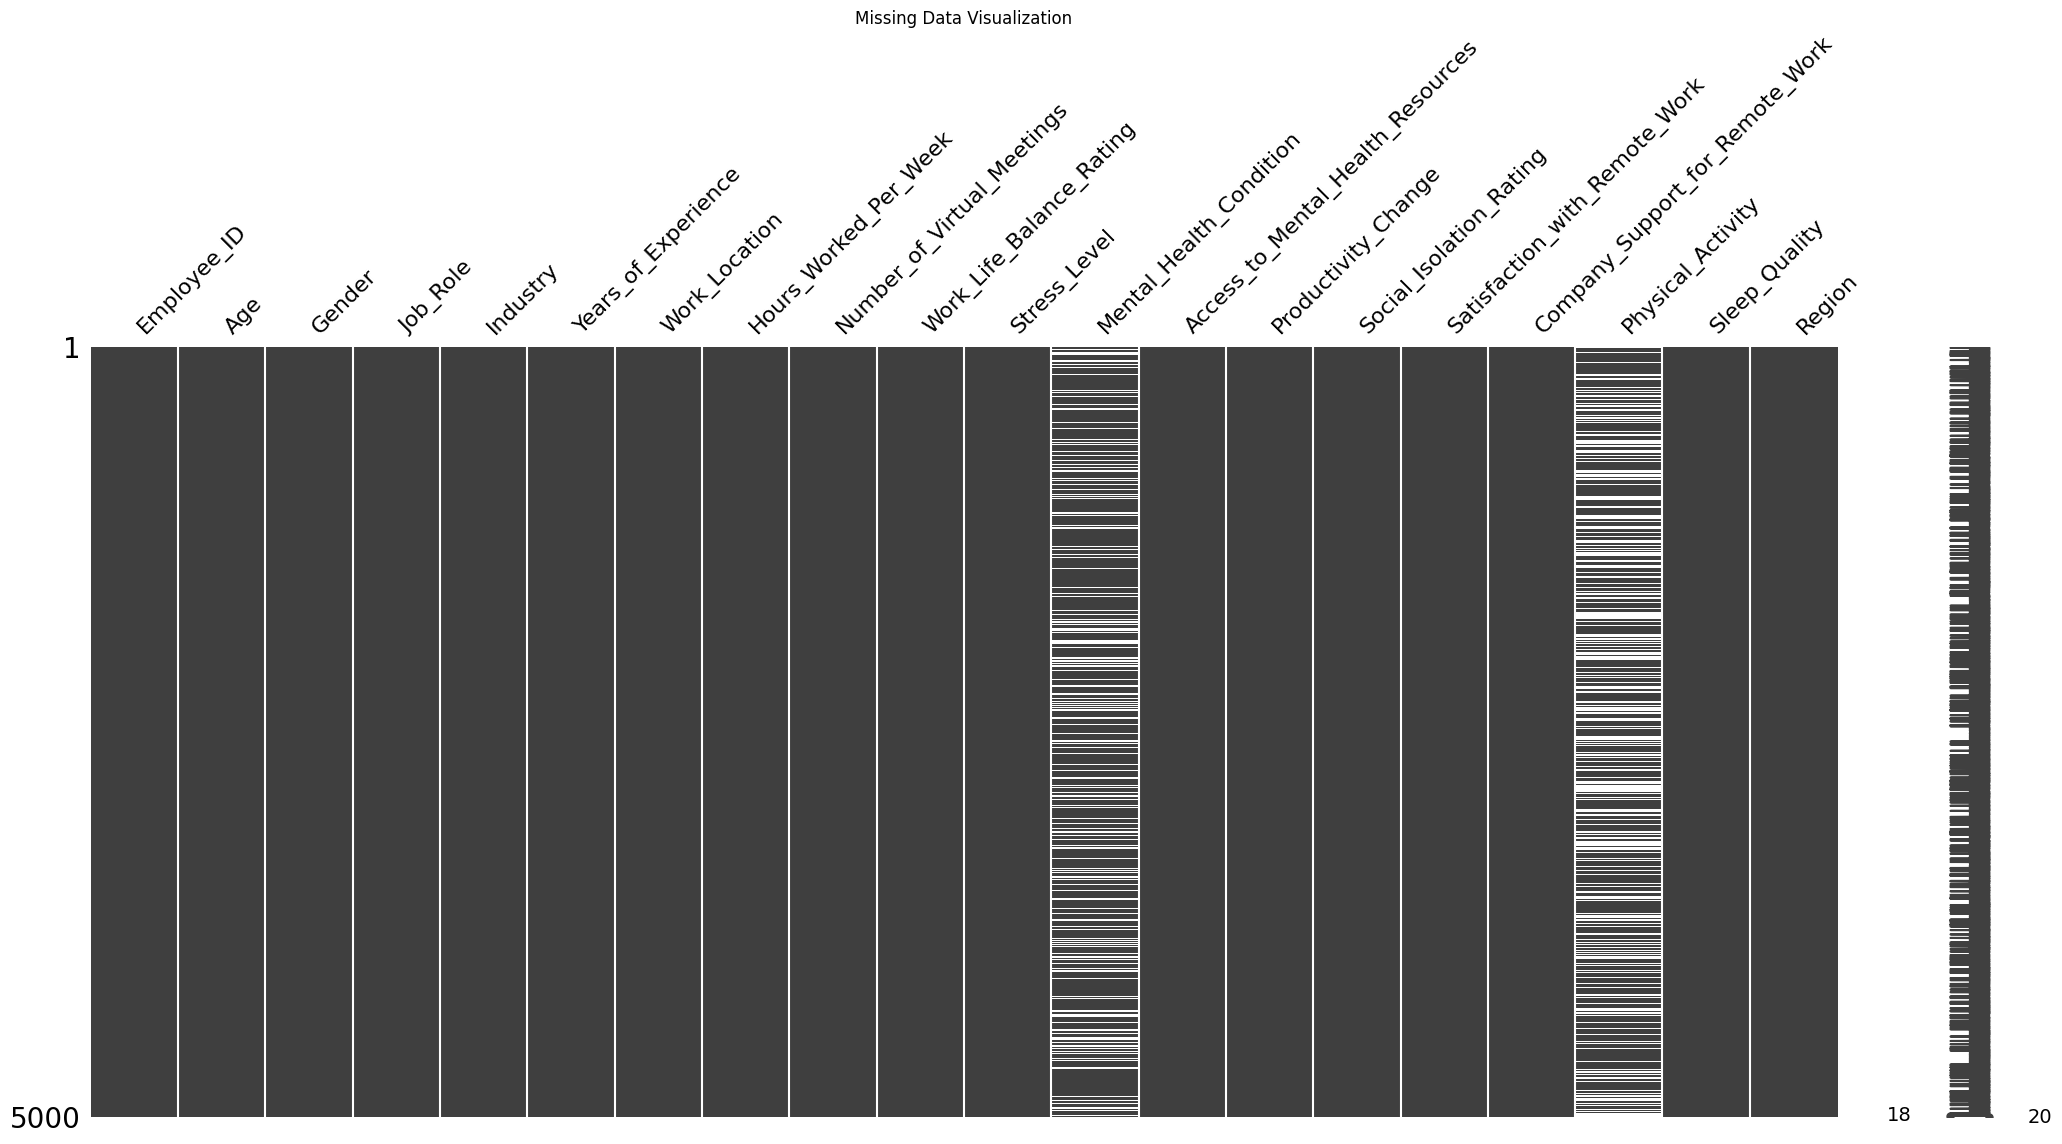

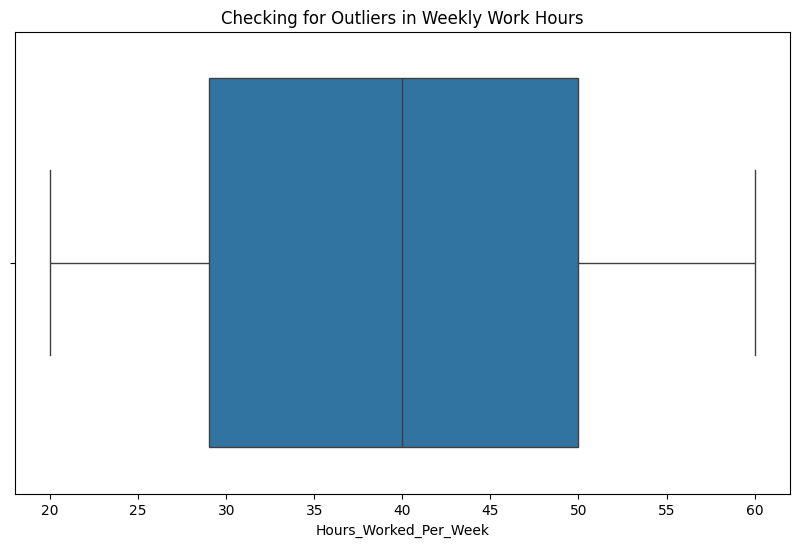

In [4]:
# Missing Values Check
print(f"Dataset Shape: {df.shape}")
msno.matrix(df)
plt.title("Missing Data Visualization")
plt.show()

# Box Plot for Work Hours
plt.figure(figsize=(10,6))
sns.boxplot(x=df['Hours_Worked_Per_Week'])
plt.title("Checking for Outliers in Weekly Work Hours")
plt.show()

# Interactive Density Heatmap
fig = px.density_heatmap(
    df, x='Hours_Worked_Per_Week', y='Work_Life_Balance_Rating', facet_col='Stress_Level',
    title='Density of Stress Levels: Work Hours vs. WLB Rating',
    template='plotly_dark'
)
fig.show()

# **4. Pipeline & Initial Training**

In [6]:
target_col = 'Stress_Level'
X = df.drop(columns=['Employee_ID', target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

NUMERIC_FEATURES = ['Age', 'Years_of_Experience', 'Hours_Worked_Per_Week', 'Number_of_Virtual_Meetings', 'Work_Life_Balance_Rating', 'Social_Isolation_Rating']
CATEGORICAL_FEATURES = ['Gender', 'Job_Role', 'Industry', 'Work_Location', 'Mental_Health_Condition', 'Access_to_Mental_Health_Resources', 'Productivity_Change', 'Satisfaction_with_Remote_Work', 'Company_Support_for_Remote_Work', 'Physical_Activity', 'Sleep_Quality', 'Region']

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', RobustScaler())]), NUMERIC_FEATURES),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), CATEGORICAL_FEATURES)
])

clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42))
])

clf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['Age', 'Years_of_Experience',
                                                   'Hours_Worked_Per_Week',
                                                   'Number_of_Virtual_Meetings',
                                                   'Work_Life_Balance_Rating',
                                                   'Social_Isolation_Rating']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Job_Role',
                                                   'Industry', 'Work_Location',
                                                   'Mental_Health_Condition',
                                                   'Access_to_Mental_Health_Resources',
                                                   'Productivity_Change',
                                                   'Satisfaction_with_Remote_Work',
                                                   'Company_Support_for_Remote_Work',
                                                   'Physical_Activity',
                                                   'Sleep_Quality',
                                                   'Region'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=12, random_state=42))])

# **5. Prediction & Performance Results**

MODEL PERFORMANCE: RANDOM FOREST
Accuracy: 0.3440

Classification Report:
              precision    recall  f1-score   support

        High       0.35      0.38      0.36       337
         Low       0.33      0.30      0.31       329
      Medium       0.36      0.35      0.35       334

    accuracy                           0.34      1000
   macro avg       0.34      0.34      0.34      1000
weighted avg       0.34      0.34      0.34      1000



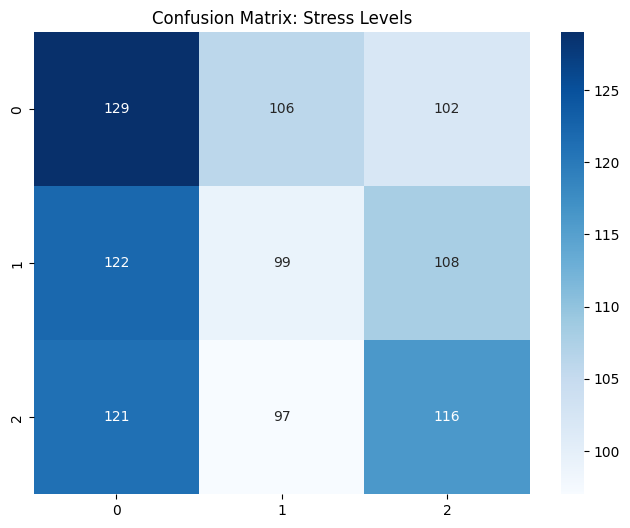

In [7]:
y_pred = clf.predict(X_test)

print("="*50)
print("MODEL PERFORMANCE: RANDOM FOREST")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix: Stress Levels")
plt.show()

# **6. Feature Importance**

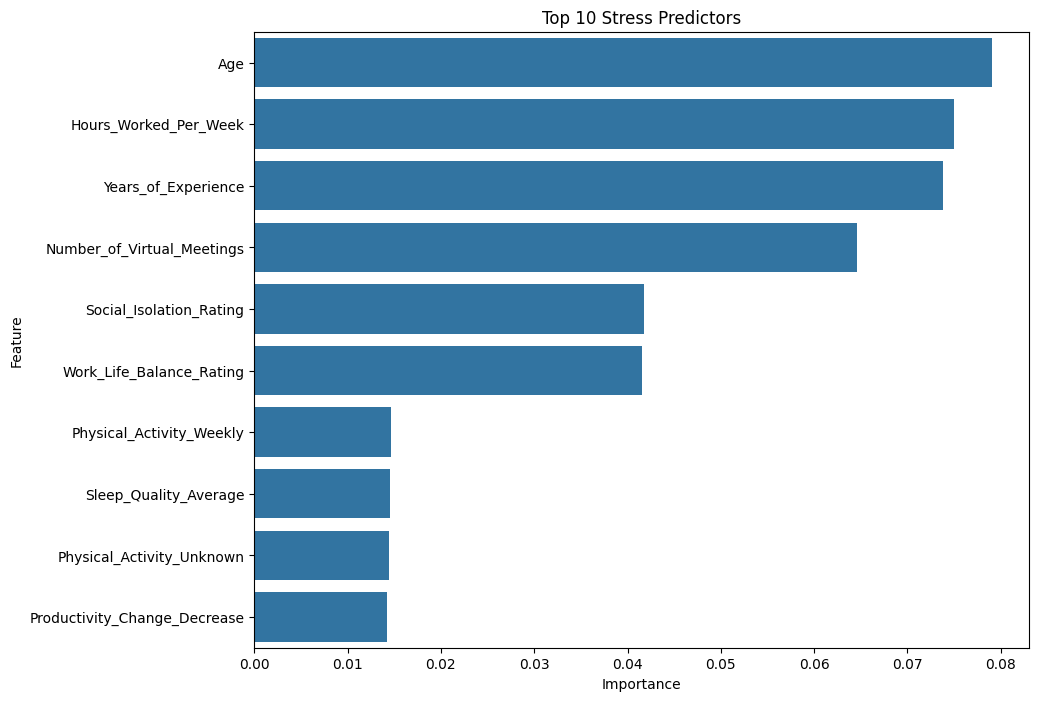

In [8]:
# Extracting names from the pipeline
onehot_names = list(clf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(CATEGORICAL_FEATURES))
all_features = NUMERIC_FEATURES + onehot_names

feature_imp = pd.DataFrame({
    'Feature': all_features,
    'Importance': clf.named_steps['classifier'].feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(10))
plt.title('Top 10 Stress Predictors')
plt.show()

# **7. Hyperparameter Tuning (GridSearchCV)**

In [9]:
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [8, 12, None],
    'classifier__min_samples_split': [5, 10],
}

print("Starting GridSearchCV...")
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("\n" + "="*50)
print("TUNED PERFORMANCE")
print("="*50)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Tuned Accuracy: {accuracy_score(y_test, y_pred_tuned):.4f}")

Starting GridSearchCV...

TUNED PERFORMANCE
Best Parameters: {'classifier__max_depth': 12, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Tuned Accuracy: 0.3630


### Reflection:
Performance Analysis: The model reached 36.3% accuracy. While this is a tough result, the Feature Importance chart provides the real value. It shows that Age, Work Hours, and Experience are the primary drivers of stress, rather than the specific industry or job role.

The "Noise" Factor: Because Age and Experience are so high on the list, it suggests that stress might be more related to a person's career stage than the remote work environment itself. This is a huge insight that wouldn't be obvious without the ML model.

Clinical vs. Survey Data: Comparing this to my Heart Disease model (85.3% accuracy), it’s clear that structured clinical data provides a much stronger signal for AI than subjective workplace surveys.

Takeaway: This project proved that even with lower predictive accuracy, we can still extract meaningful trends (like the impact of work hours) that help us understand the "why" behind the data.